#KNN - K-Nearest Neighbors

# O KNN (K-Nearest Neighbors)
- Sendo as duas figuras abaixo,
<img src="https://drive.google.com/uc?id=1zOFK8Juc09PUh_UCqQ84aVC32RaGG5Ix" style='width: 600px;' />

Podemos nos perguntar: "Qual seria a cor do ponto vermelho na primeira figura? E na segunda?"

Por que pensamos que o primeiro ponto é roxo e o segundo é amarelo? Suponhamos que, se todos os pontos em uma região têm a mesma cor, é mais provável que um novo ponto nessa área também compartilhe essa cor, já que apresentam características semelhantes. Essa é exatamente a lógica utilizada pelo algoritmo KNN (K-Nearest Neighbors)!

Sendo um dos algoritmos mais simples, o KNN utiliza a similaridade entre os k pontos mais próximos no conjunto de dados para estimar o valor das novas observações. Todo o processamento ocorre no momento da previsão, por isso o KNN é conhecido como um tipo de "aprendizado preguiçoso" (lazy learning). Embora seja simples, isso pode ser bastante custoso em conjuntos de dados grandes, especialmente quando é necessário fazer previsões rápidas.

Por padrão, cada ponto contribui igualmente na previsão. No entanto, é possível ajustar o hiperparâmetro "weights" para "distance", o que faz com que os pontos mais próximos tenham maior influência na estimativa. Outra abordagem é usar o RadiusNeighborsClassifier, que considera apenas os pontos vizinhos dentro de um raio específico.

**Atenção**: tenha cuidado ao usar o KNN com variáveis em escalas muito diferentes!

Algoritmo utilizado para classificação com explicação bastante simples.
Basta seguir o passo a passo:

- Escolha o número de K vizinhos avaliados (default no sktlearn = 5). Use números ímpares;
- Pegue os K vizinhos mais próximos segundo uma métrica de avaliação de distância pré-determinada (como a distância Euclidiana);
- Dentre estes K vizinhos, conte as categorias;
- O novo ponto terá a categoria do mais votado.


Precisa de todos os dados para fazer a previsão, mesmo depois de ter o algoritmo treinado!

In [1]:
import numpy as np
#import matplotlib.pyplot as plt
#from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns

#from sklearn import tree

#from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.ensemble import RandomForestRegressor

#from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#from sklearn.svm import SVC

#from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import GridSearchCV

#from sklearn.metrics import r2_score
#from sklearn.metrics import mean_absolute_error

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
titanic = sns.load_dataset("titanic")


In [3]:
titanic.drop('deck',  axis=1, inplace=True)

In [4]:
dataset2 = titanic.dropna(axis=0) #retira as linhas com NaN

In [5]:
y = dataset2.survived

In [6]:
features = ['pclass', 'age', 'sibsp', 'fare', 'parch']

X = dataset2[features].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [8]:
X_train


array([[  1.    ,  31.    ,   0.    ,  50.4958,   0.    ],
       [  1.    ,  38.    ,   0.    , 153.4625,   1.    ],
       [  2.    ,  35.    ,   0.    ,  26.    ,   0.    ],
       ...,
       [  2.    ,  16.    ,   0.    ,  26.    ,   0.    ],
       [  2.    ,  39.    ,   0.    ,  26.    ,   0.    ],
       [  3.    ,  24.    ,   0.    ,  19.2583,   3.    ]])

In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:, 2:] = sc.fit_transform(X_train[:, 2:]) #faz fit e transforma nos dados de treino
X_test[:, 2:] = sc.transform(X_test[:, 2:]) #nunca usar dados de teste para fazer fit! usar o mesmo scaler para escalar os dados de teste.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2) #minkowski feito com p = 2 é a distância euclidiana
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [12]:
y_pred = classifier.predict(X_test)

In [13]:
accuracy_score(y_test, y_pred)

0.6923076923076923

In [14]:
features = ['pclass', 'age', 'sibsp', 'fare','adult_male']

X = dataset2[features].values
y = dataset2.survived

In [15]:
X = np.array(ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [-1])], remainder='passthrough').fit_transform(X))


In [16]:
X

array([[0.0, 1.0, 3, 22.0, 1, 7.25],
       [1.0, 0.0, 1, 38.0, 1, 71.2833],
       [1.0, 0.0, 3, 26.0, 0, 7.925],
       ...,
       [1.0, 0.0, 1, 19.0, 0, 30.0],
       [0.0, 1.0, 1, 26.0, 0, 30.0],
       [0.0, 1.0, 3, 32.0, 0, 7.75]], dtype=object)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [18]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:, 2:] = sc.fit_transform(X_train[:, 2:]) #faz fit e transforma nos dados de treino
X_test[:, 2:] = sc.transform(X_test[:, 2:]) #nunca usar dados de teste para fazer fit! usar o mesmo scaler para escalar os dados de teste.

In [47]:
classifier = KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 5) #minkowski feito com p = 2 é a distância euclidiana
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7, p=5)

In [48]:
y_pred = classifier.predict(X_test)

In [49]:
accuracy_score(y_test, y_pred)

0.8111888111888111

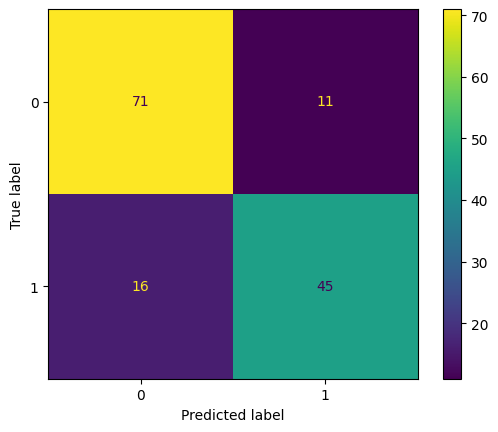

In [50]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();
